## 1. Initial setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import scipy as sp

In [2]:
#Climate data
dt = xr.open_datatree("E:/MAXIM/regridded", engine="zarr") #datatree

In [3]:
#Height data
ds_height = xr.open_dataset("E:/MAXIM/CCLM_orog_remapped.nc") #CCLM height map

In [4]:
#dt

In [5]:
#ds_height

In [6]:
ds_observations = dt["/observations/CLIMATE_GRID"].to_dataset()[["pr"]] #observations, rain
ds_MAR = dt["/RCM/MAR"].to_dataset()[["pr"]]                            #MAR, rain
ds_ALARO = dt["/RCM/ALARO1-SFX"].to_dataset()[["pr"]]                   #ALARO, rain
ds_CCLM = dt["/RCM/CCLM"].to_dataset()[["pr"]]                          #CCLM, rain

#Cleaning dims (# Drops any coordinate that is not a primary dimension (like time, lat, lon))
ds_MAR = ds_MAR.reset_coords(drop=True)
ds_CCLM = ds_CCLM.reset_coords(drop=True)
ds_ALARO = ds_ALARO.reset_coords(drop=True)

ds_height = ds_height.drop_vars("time") #remove this one timestamp

#Convert units from kg/m2/s to mm/day
ds_observations['pr'] = ds_observations['pr'] * 86400
ds_MAR['pr']          = ds_MAR['pr'] * 86400
ds_CCLM['pr']         = ds_CCLM['pr'] * 86400
ds_ALARO['pr']        = ds_ALARO['pr'] * 86400

#Correcting names
for dataset in [ds_observations, ds_MAR, ds_CCLM, ds_ALARO]:
    dataset['pr'].attrs['units'] = 'mm/day'


#Matching modeled grid outcuts with observations
spatial_mask = ds_observations['pr'].isel(time=0).notnull()

ds_MAR   = ds_MAR.reindex_like(ds_observations, method='nearest').where(spatial_mask)
ds_CCLM  = ds_CCLM.reindex_like(ds_observations, method='nearest').where(spatial_mask)
ds_ALARO = ds_ALARO.reindex_like(ds_observations, method='nearest').where(spatial_mask)
ds_height = ds_height.reindex_like(ds_observations, method='nearest').where(spatial_mask)


#Defining data dictionary
models = {
    'CCLM': ds_CCLM,
    'ALARO': ds_ALARO,
    'MAR': ds_MAR
}


## 2. Exploratory analysis part 1: missing data

In [7]:
#NA check
print("=== TOTAL ALL-NA DAYS COUNT (1985–2025) ===")

# Initialize a dictionary to store the NA dates
all_na_dates = {}

# Combine models and observations dynamically into a single loop
for name, ds in {**models, 'Observations': ds_observations}.items():
    print(f"\nModel: {name}")
    try:
        # 1. Slice to the requested 1985-2025 window
        pr_slice = ds.pr.sel(time=slice('1985-01-01', '2025-12-31'))

        # 2. Check where the ENTIRE map consists of NA values for each day
        is_na_day = pr_slice.isnull().all(dim=['lat', 'lon'])

        # 3. Extract the exact dates that meet the all-NA condition
        na_dates = pr_slice.time.where(is_na_day, drop=True).values
        total_na_days = len(na_dates)

        # Save the dates as a pandas DatetimeIndex
        all_na_dates[name] = pd.to_datetime(na_dates)

        print(f"  Total completely missing (all-NA) days: {total_na_days}")

        if total_na_days > 0:
            # Turn into a pandas Series to easily count frequencies per year
            df_na = pd.Series(1, index=all_na_dates[name])

            # Resample by Year-End and map index directly to Year for cleaner output
            df_yearly = df_na.resample('YE').sum()
            df_yearly.index = df_yearly.index.year
            df_yearly.index.name = 'Year'

            print("  Breakdown of missing days by year:")
            print(df_yearly.to_string(header=False))
        else:
            print("  Clean dataset! No entirely missing grids found.")

    except Exception as e:
        print(f"Could not process model '{name}': {e}")

=== TOTAL ALL-NA DAYS COUNT (1985–2025) ===

Model: CCLM
  Total completely missing (all-NA) days: 105
  Breakdown of missing days by year:
1987    105

Model: ALARO
  Total completely missing (all-NA) days: 0
  Clean dataset! No entirely missing grids found.

Model: MAR
  Total completely missing (all-NA) days: 0
  Clean dataset! No entirely missing grids found.

Model: Observations
  Total completely missing (all-NA) days: 0
  Clean dataset! No entirely missing grids found.


In [8]:
# Print out a summary list of all NA dates for models that contain them
for name, dates in all_na_dates.items():
    if len(dates) > 0:
        print(f"\nMissing dates for {name}:")
        print(dates.strftime('%Y-%m-%d').tolist())


Missing dates for CCLM:
['1987-01-03', '1987-01-08', '1987-01-13', '1987-01-19', '1987-01-24', '1987-01-29', '1987-02-03', '1987-02-08', '1987-02-13', '1987-02-18', '1987-02-23', '1987-02-28', '1987-03-05', '1987-03-10', '1987-03-15', '1987-03-21', '1987-03-26', '1987-03-31', '1987-04-04', '1987-04-07', '1987-04-09', '1987-04-12', '1987-04-14', '1987-04-18', '1987-04-19', '1987-04-21', '1987-04-23', '1987-04-24', '1987-04-28', '1987-04-29', '1987-05-03', '1987-05-04', '1987-05-08', '1987-05-09', '1987-05-13', '1987-05-14', '1987-05-18', '1987-05-19', '1987-05-23', '1987-05-25', '1987-05-27', '1987-05-28', '1987-05-30', '1987-06-02', '1987-06-04', '1987-06-07', '1987-06-09', '1987-06-12', '1987-06-14', '1987-06-17', '1987-06-19', '1987-06-22', '1987-06-24', '1987-06-27', '1987-06-29', '1987-07-03', '1987-07-13', '1987-07-18', '1987-08-07', '1987-08-13', '1987-08-23', '1987-08-28', '1987-09-07', '1987-09-12', '1987-09-17', '1987-09-22', '1987-09-27', '1987-10-03', '1987-10-06', '1987-10

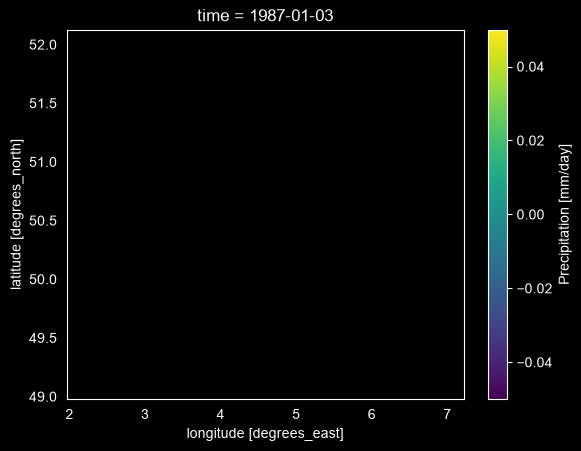

In [9]:
ds_CCLM.pr.sel(time='1987-01-03').plot()

In [10]:
def filter_years_lazy(ds):
    # Extract the lightweight 1D metadata time index
    time_index = ds.indexes['time']

    # Create a boolean mask: Keep 1985 to 2022 #removing 2023, 2024, 2025 because they were not simulated
    # (normally 1987 should also be removed...)
    mask = (time_index.year >= 1985) & (time_index.year <= 2022)

    # Extract only the explicit dates we want to keep
    valid_dates = time_index[mask]

    # Select them lazily
    return ds.sel(time=valid_dates)

# Apply to all datasets
ds_observations, ds_MAR, ds_CCLM, ds_ALARO = [
    filter_years_lazy(ds) for ds in [ds_observations, ds_MAR, ds_CCLM, ds_ALARO]
]

#Overwriting models now with the correct time values
models = {
    'CCLM': ds_CCLM,
    'ALARO': ds_ALARO,
    'MAR': ds_MAR
}

## 2. Exploratory analysis part 2: rainfall

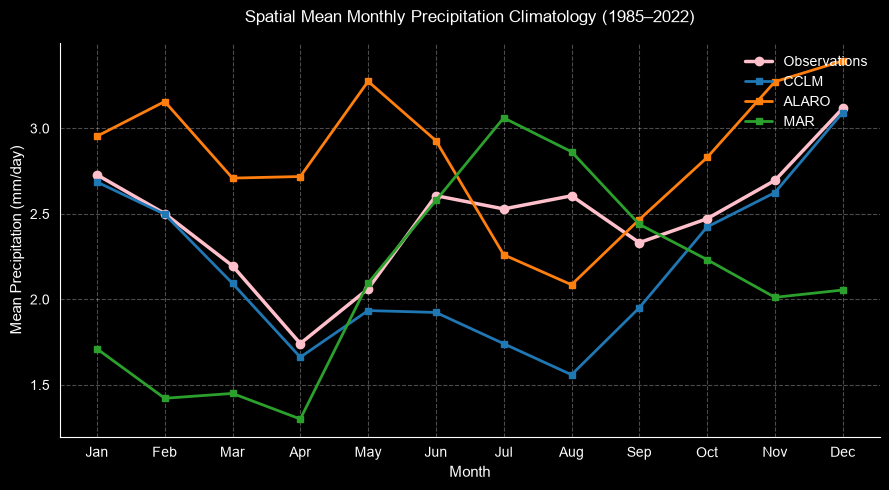

In [11]:
# 1. Compute spatial-regional mean grouped by month
seasonal_obs = ds_observations.pr.groupby('time.month').mean(dim=['time', 'lat', 'lon'])

plt.figure(figsize=(9, 5))

# Plot observations
plt.plot(seasonal_obs.month, seasonal_obs, label='Observations', color='pink', linewidth=2.5, marker='o')

# Plot models using a consistent color palette matching your distribution plot
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}
for name, ds in models.items():
    seasonal_mod = ds.pr.groupby('time.month').mean(dim=['time', 'lat', 'lon'])
    plt.plot(seasonal_mod.month, seasonal_mod, label=name, color=colors.get(name), linewidth=2, marker='s', markersize=5)

# Formatting details
plt.title('Spatial Mean Monthly Precipitation Climatology (1985–2022)', fontsize=12, pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Mean Precipitation (mm/day)', fontsize=11)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(linestyle='--', alpha=0.3)
plt.legend(frameon=False, loc='upper right')

# Clean minimalist layout
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

#### Fig 1: Climatology of monthly precipitation (rain in time)
 ##### Methodology: Calculated by taking the mean of time and space per month of rainfall.

 ##### Result + Discussion: is this a lot of variation?

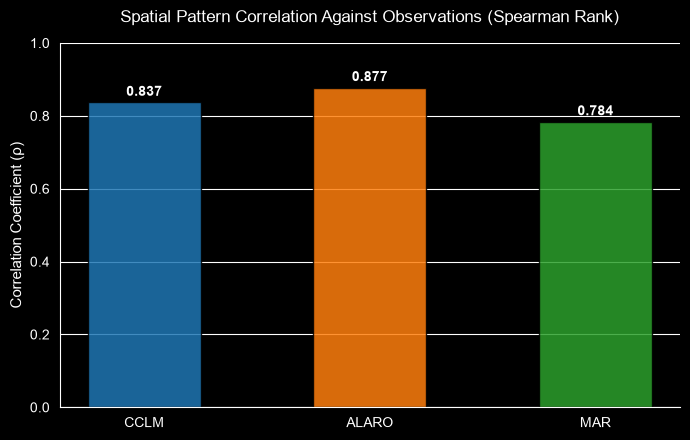

In [12]:
# 1. Compute long-term spatial mean maps for all datasets
spatial_means = {'Observations': ds_observations.pr.mean(dim='time')}
for name, ds in models.items():
    spatial_means[name] = ds.pr.mean(dim='time')

# 2. Flatten maps into a pandas DataFrame to calculate Spearman correlation
df_spatial = pd.DataFrame({name: field.values.flatten() for name, field in spatial_means.items()})
df_spatial = df_spatial.dropna()  # Remove grid cells outside the spatial domain mask

#Calculate spearman
corr_matrix = df_spatial.corr(method='spearman')

# 3. Extract only the correlations of model and observations (and drop Obs-vs-Obs itself because this would be 1)
obs_corr = corr_matrix['Observations'].drop('Observations')

# 4. Plot as an elegant bar chart
plt.figure(figsize=(7, 4.5))

# Colors
colors_dict = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}
bar_colors = [colors_dict[name] for name in obs_corr.index]

bars = plt.bar(obs_corr.index, obs_corr.values, color=bar_colors, width=0.5, edgecolor='black', alpha=0.85)

# Add value labels on top of the bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.01, f"{height:.3f}",
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.title('Spatial Pattern Correlation Against Observations (Spearman Rank)', fontsize=12, pad=15)
plt.ylabel('Correlation Coefficient (ρ)', fontsize=11)
plt.ylim(0, 1.0)  # Standard correlation scale
plt.grid(axis='x', linestyle='--', alpha=0)

# Style cleanup
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

#### Fig 2: Spatial spearman correlation (rain location in space)

##### Methodology: Calculated by taking the spearman correlation between the time-means of each pixel of a model to the same pixel of obs.

##### Result + Discussion: Greater spearman correlation indicates greater spatial correctness (without looking at amount biases, ranks ...). This spatial correctness is also necessary to fit a GEV pixelwise because we are fitting a GEV to rain that actually fell there. => GEV least reliable with MAR

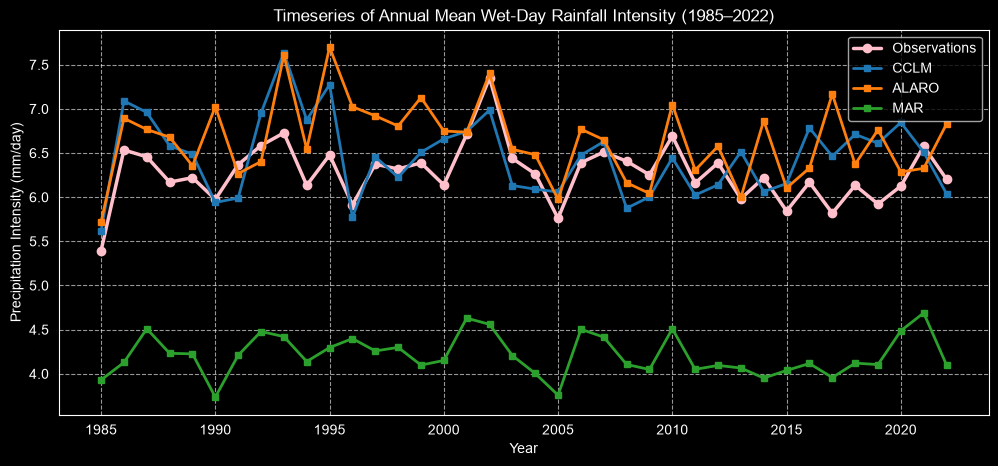

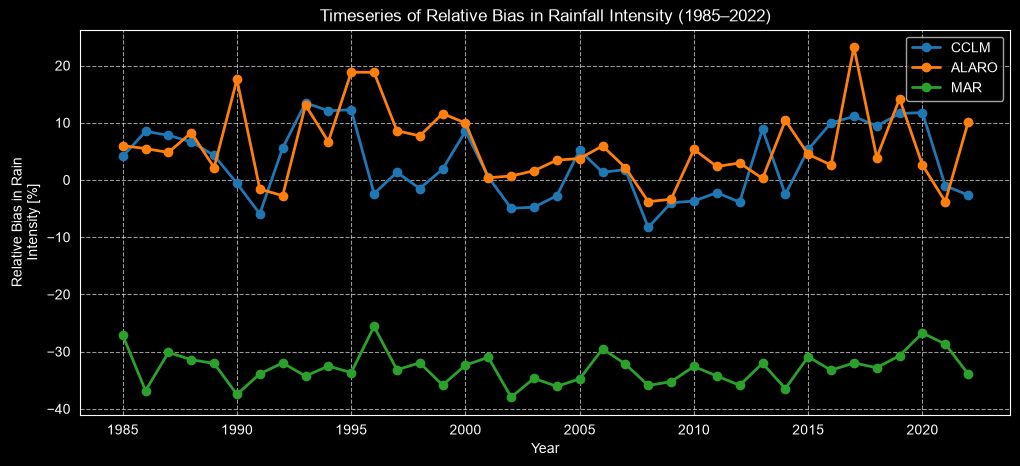

In [13]:
# ==============================================================================
# --- PRE-CALCULATE ANNUAL RAIN INTENSITY (SDII) IN TIME ---
# ==============================================================================
# Calculate annual mean intensity for days where precipitation >= 1.0 mm/day
sdii_time_obs = ds_observations.pr.where(ds_observations.pr >= 1.0).resample(time='YE').mean(dim=['time', 'lat', 'lon'])  # sum P_wet days / number_wet days

sdii_time_models = {}
for name, ds in models.items():
    sdii_time_models[name] = ds.pr.where(ds.pr >= 1.0).resample(time='YE').mean(dim=['time', 'lat', 'lon'])  # sum P_wet days / number_wet days

# Consistent color palette matching your notebook
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}


# ==============================================================================
# --- PLOT 1: Raw SDII Values Over Time ---
# ==============================================================================
plt.figure(figsize=(12, 5))

# Plot observations raw values (clean time axis to show just the year)
obs_plot = sdii_time_obs.assign_coords(time=sdii_time_obs.time.dt.year)
obs_plot.plot(label='Observations', color='pink', marker='o', linewidth=2.5)

# Plot model raw values
for name, sdii_mod in sdii_time_models.items():
    model_plot = sdii_mod.assign_coords(time=sdii_mod.time.dt.year)
    model_plot.plot(label=name, color=colors[name], marker='s', linewidth=2, markersize=5)

plt.title('Timeseries of Annual Mean Wet-Day Rainfall Intensity (1985–2022)')
plt.ylabel('Precipitation Intensity (mm/day)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()


# ==============================================================================
# --- PLOT 2: SDII Relative Bias Over Time ---
# ==============================================================================
plt.figure(figsize=(12, 5))

for name, sdii_mod in sdii_time_models.items():
    # Calculate yearly relative bias in intensity
    yearly_intensity_bias = ((sdii_mod - sdii_time_obs) / sdii_time_obs) * 100

    # Assign attributes for auto-labeling
    yearly_intensity_bias.attrs['long_name'] = 'Relative Bias in Rain Intensity'
    yearly_intensity_bias.attrs['units'] = '%'

    # Clean coordinate formatting for the X-axis
    yearly_intensity_bias = yearly_intensity_bias.assign_coords(time=yearly_intensity_bias.time.dt.year)

    # Plot the relative bias
    yearly_intensity_bias.plot(label=name, color=colors[name], marker='o', linewidth=2)

plt.title('Timeseries of Relative Bias in Rainfall Intensity (1985–2022)')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

#### Fig 3 + 4: SDII timeseries (rain intensity in time), (values + bias)
 ##### Methodology: SDII is calculated as filtering days, for all days available per year, when there is rain (>=1mm/day) and summing the total of these rain days / number of rainy days averaged in space. Finally, this was also expresse in terms of relative bias.

 ##### Result + Discussion

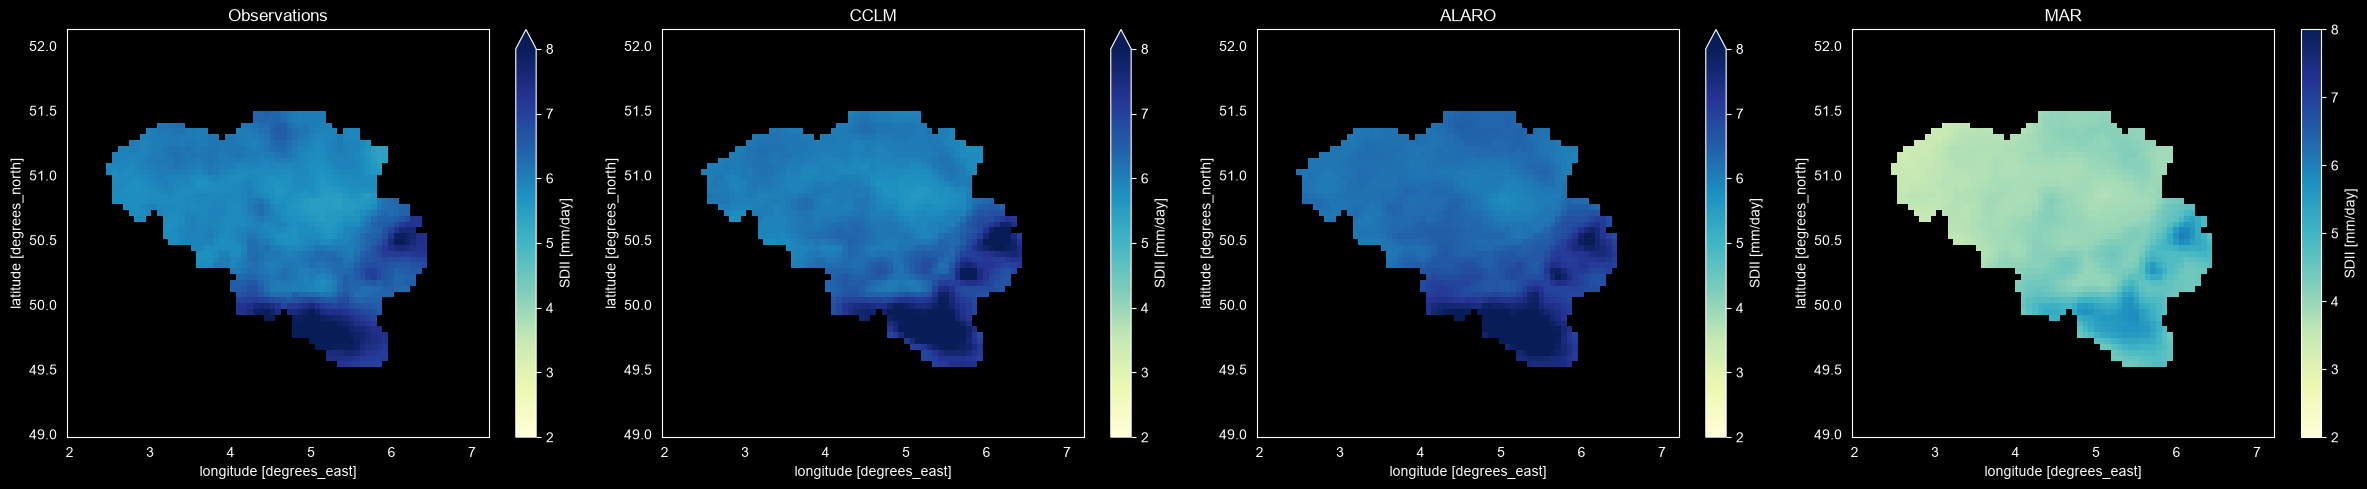

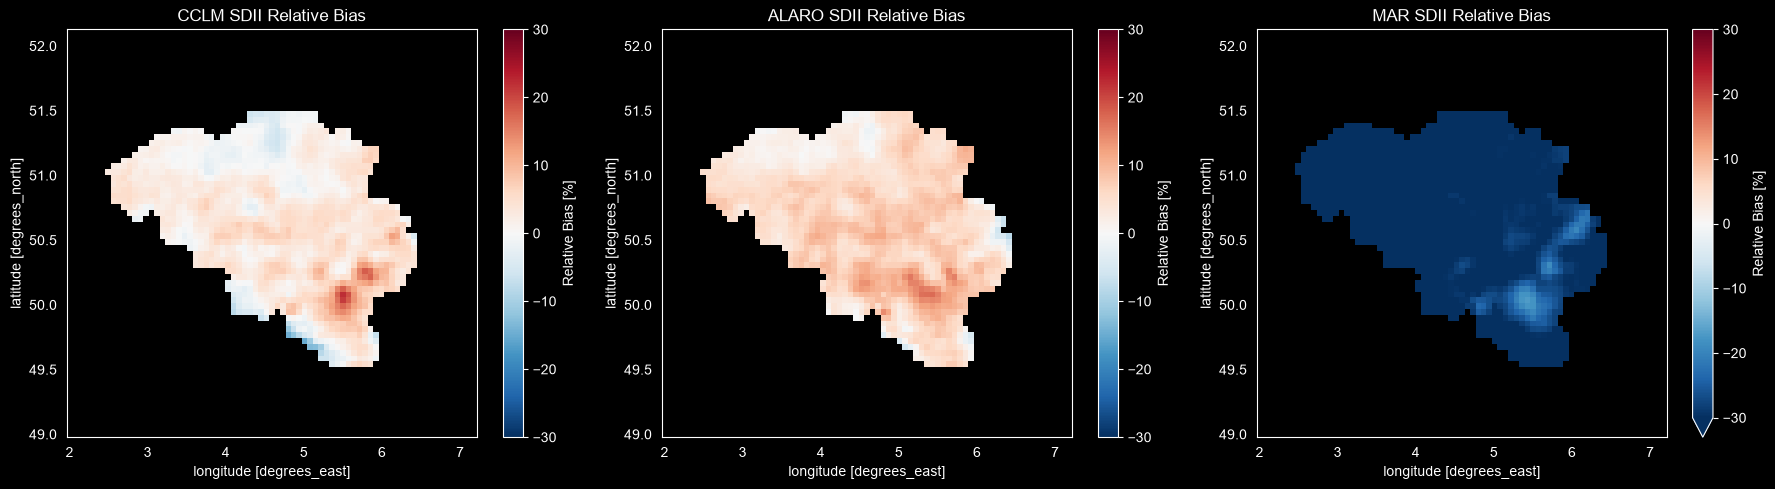

In [14]:
# 1. Calculate Simple Daily Intensity Index (SDII) aka if it rains, how hard it rains - Mean wet-day precipitation (pr >= 1 mm/day)
sdii_obs = ds_observations.pr.where(ds_observations.pr >= 1.0).mean(dim='time') # sum P_wet days / number_wet days
sdii_models = {}

plt.figure(figsize=(24, 5))

# Plot Observations
plt.subplot(1, 4, 1)
sdii_obs.attrs['long_name'] = 'SDII'
sdii_obs.attrs['units'] = 'mm/day'
sdii_obs.plot(vmin=2, vmax=8, cmap='YlGnBu')
plt.title('Observations')

# Plot Models dynamically inside your dictionary structure
for i, name in enumerate(models.keys(), start=2):
    plt.subplot(1, 4, i)

    sdii_models[name] = models[name].pr.where(models[name].pr >= 1.0).mean(dim='time')
    sdii_models[name].attrs['long_name'] = 'SDII'
    sdii_models[name].attrs['units'] = 'mm/day'
    sdii_models[name].plot(vmin=2, vmax=8, cmap='YlGnBu')
    plt.title(name)

plt.tight_layout()


# 2. Subplot of the SDII Relative Biases ((Modelled - Observed) / Observed) * 100
plt.figure(figsize=(18, 5))

for i, name in enumerate(models.keys(), start=1):
    plt.subplot(1, 3, i)

    bias_sdii = ((sdii_models[name] - sdii_obs) / sdii_obs) * 100
    bias_sdii.attrs['long_name'] = 'Relative Bias'
    bias_sdii.attrs['units'] = '%'
    bias_sdii.plot(cmap='RdBu_r', vmin=-30, vmax=30)
    plt.title(f'{name} SDII Relative Bias')

plt.tight_layout()

#### Fig 5 + 6: SDII pixelwise (rain intensity in space), (values + bias)
 ##### Methodology: SDII is calculated pixelwise as filtering days, for all days available for all the given years, when there is rain (>=1mm/day) and summing the total of these rain days / number of rainy days. Finally, this was also expresse in terms of relative bias.

 ##### Result + Discussion

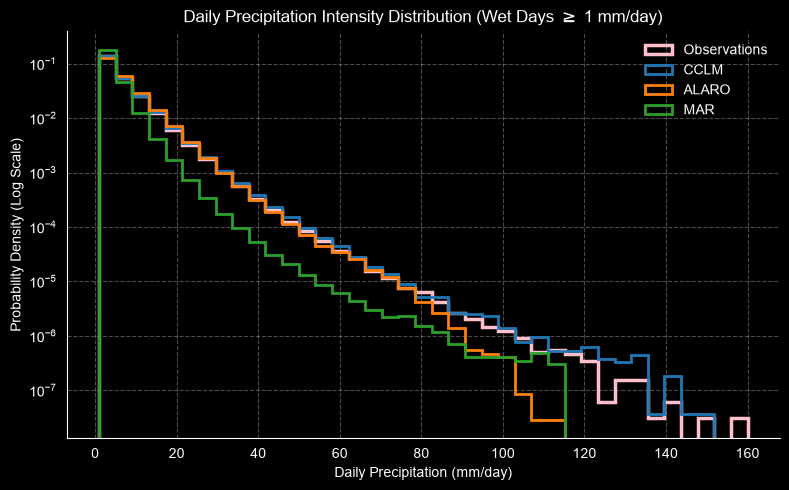

In [15]:
# 3. Daily rainfall intensity distribution (Spatially pooled over the grid for wet days)
plt.figure(figsize=(8, 5))

# Define intensity bins from 1 mm/day up to 80 mm/day to capture heavy tail behaviors
bins = np.linspace(1, 160, 40)  #start, stop, nbins

# Extract and flatten wet-day data for observations
obs_values = ds_observations.pr.values.flatten()
obs_wet = obs_values[(~np.isnan(obs_values)) & (obs_values >= 1.0)]

# Plot Observations distribution
plt.hist(obs_wet, bins=bins, density=True, histtype='step', linewidth=2.5,
         color='pink', label='Observations', log=True)

# Coordinated distinct color scheme for the models
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}

# Loop and plot each model's pooled rainfall distribution
for name, ds in models.items():
    mod_values = ds.pr.values.flatten()
    mod_wet = mod_values[(~np.isnan(mod_values)) & (mod_values >= 1.0)]
    plt.hist(mod_wet, bins=bins, density=True, histtype='step', linewidth=2.0,
             color=colors[name], label=name, log=True)
    #density true, to make density under curve 1 aka normalizing to get probabilities
    #step to make columns hollow

plt.title('Daily Precipitation Intensity Distribution (Wet Days $\geq$ 1 mm/day)')
plt.xlabel('Daily Precipitation (mm/day)')
plt.ylabel('Probability Density (Log Scale)')
plt.grid(axis='both', linestyle='--', alpha=0.3)
plt.legend(frameon=False)

# Clean minimalist style adjustments matching your boxplot
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

#### Fig 7: PDF of rain (step towards extremes)
 ##### Methodology: Calculated by flattening all data and filtering wet days (>=1mm) and plotting it in a standarised histogram to obtain PDF.

 ##### Result + Discussion: MAR has a lot of underestimation and cannot reach extreme enough rain and compensates this by having more very light rain (drizzle). ALARO pretty good but doesnt provide the very extreme rain. CCLM pretty good but very extreme rain a bit shaky.

## 3. Extreme rainfall analysis

In [16]:
# 1. Calculate annual maxima values and the specific days they occurred for observations
ann_max_obs = ds_observations.pr.resample(time='YE').max()
ann_max_obs_day = ds_observations.pr.resample(time='YE').map(lambda x: x.idxmax(dim='time'))

# 2. Calculate annual maxima values and the specific days they occurred for all models
ann_max_models = {
    name: ds.pr.resample(time='YE').max()
    for name, ds in models.items()
}

ann_max_models_day = {
    name: ds.pr.resample(time='YE').map(lambda x: x.idxmax(dim='time'))
    for name, ds in models.items()
}

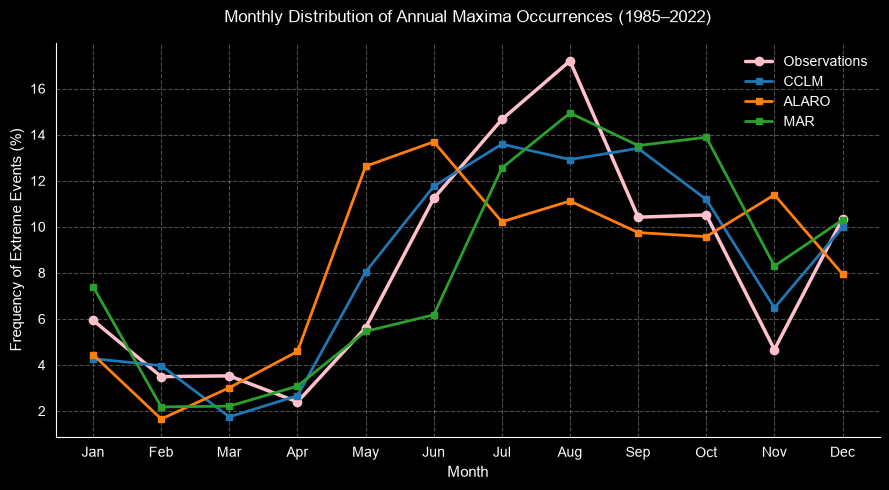

In [17]:
# 1. Define months array (1 to 12)
months = np.arange(1, 13)

# 2. Extract and flatten occurrence months for observations
obs_months = ann_max_obs_day.dt.month.values.flatten()
obs_months = obs_months[~np.isnan(obs_months)]
# Compute the percentage of extremes occurring in each month
obs_pct = [(obs_months == m).sum() / len(obs_months) * 100 for m in months]

plt.figure(figsize=(9, 5))

# Plot observations (retaining your pink styling)
plt.plot(months, obs_pct, label='Observations', color='pink', linewidth=2.5, marker='o')

# 3. Process and plot models dynamically using your color palette
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}
for name, da_day in ann_max_models_day.items():
    mod_months = da_day.dt.month.values.flatten()
    mod_months = mod_months[~np.isnan(mod_months)]
    # Compute the percentage of extremes occurring in each month for the model
    mod_pct = [(mod_months == m).sum() / len(mod_months) * 100 for m in months]

    plt.plot(months, mod_pct, label=name, color=colors.get(name), linewidth=2, marker='s', markersize=5)

# Formatting details matching your original setup
plt.title('Monthly Distribution of Annual Maxima Occurrences (1985–2022)', fontsize=12, pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Frequency of Extreme Events (%)', fontsize=11)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(linestyle='--', alpha=0.3)
plt.legend(frameon=False, loc='upper right')

# Clean minimalist layout matching your book style
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

#### Fig 8: Monthly relative frequence of annual maxima.
 ##### Methodology: Calculated by normalising the total number of occurrences of all extracted annual maxima per month, expressed as a percentage.

 ##### Result + Discussion: 

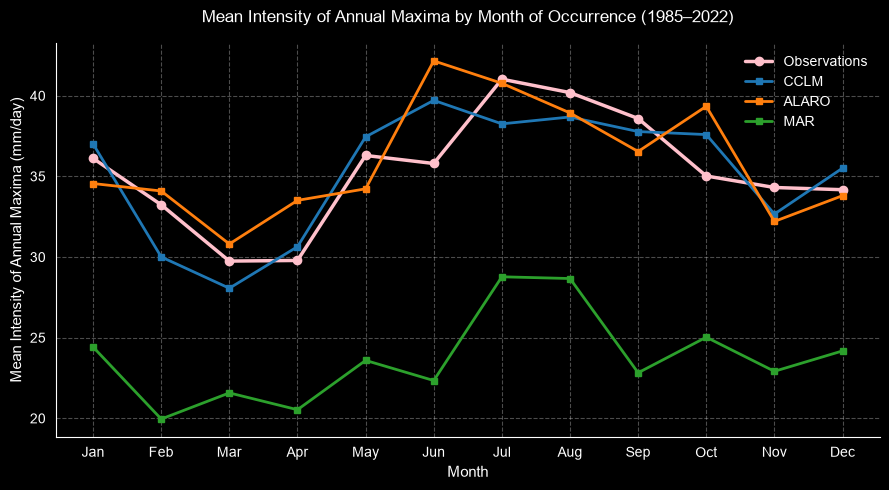

In [18]:
# 1. Define months array (1 to 12)
months = np.arange(1, 13)

# 2. Extract and flatten annual maxima values and their occurrence months for observations
obs_vals = ann_max_obs.values.flatten()
obs_months = ann_max_obs_day.dt.month.values.flatten()

# Filter out NaNs/NaTs
valid_obs = (~np.isnan(obs_vals)) & (~np.isnan(obs_months))
obs_vals_clean = obs_vals[valid_obs]
obs_months_clean = obs_months[valid_obs]

# Calculate mean intensity of annual maxima for each month
obs_intensity_by_month = []
for m in months:
    mask = (obs_months_clean == m)
    if np.any(mask):
        obs_intensity_by_month.append(np.mean(obs_vals_clean[mask]))
    else:
        obs_intensity_by_month.append(np.nan)

plt.figure(figsize=(9, 5))

# Plot observations (retaining your pink styling)
plt.plot(months, obs_intensity_by_month, label='Observations', color='pink', linewidth=2.5, marker='o')

# 3. Process and plot models dynamically using your color palette
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}
for name in models.keys():
    mod_vals = ann_max_models[name].values.flatten()
    mod_months = ann_max_models_day[name].dt.month.values.flatten()

    # Filter out NaNs/NaTs
    valid_mod = (~np.isnan(mod_vals)) & (~np.isnan(mod_months))
    mod_vals_clean = mod_vals[valid_mod]
    mod_months_clean = mod_months[valid_mod]

    # Calculate mean intensity of annual maxima for each month for the model
    mod_intensity_by_month = []
    for m in months:
        mask = (mod_months_clean == m)
        if np.any(mask):
            mod_intensity_by_month.append(np.mean(mod_vals_clean[mask]))
        else:
            mod_intensity_by_month.append(np.nan)

    plt.plot(months, mod_intensity_by_month, label=name, color=colors.get(name), linewidth=2, marker='s', markersize=5)

# Formatting details matching your original setup
plt.title('Mean Intensity of Annual Maxima by Month of Occurrence (1985–2022)', fontsize=12, pad=15)
plt.xlabel('Month', fontsize=11)
plt.ylabel('Mean Intensity of Annual Maxima (mm/day)', fontsize=11)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(linestyle='--', alpha=0.3)
plt.legend(frameon=False, loc='upper right')

# Clean minimalist layout matching your book style
ax = plt.gca()
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

#### Fig 9: Monthly mean intensity of annual maxima.
 ##### Methodology: Calculated by taking the mean per month of the intensities of all extracted annual maxima, expressed in mm/day.

 ##### Result + Discussion: 

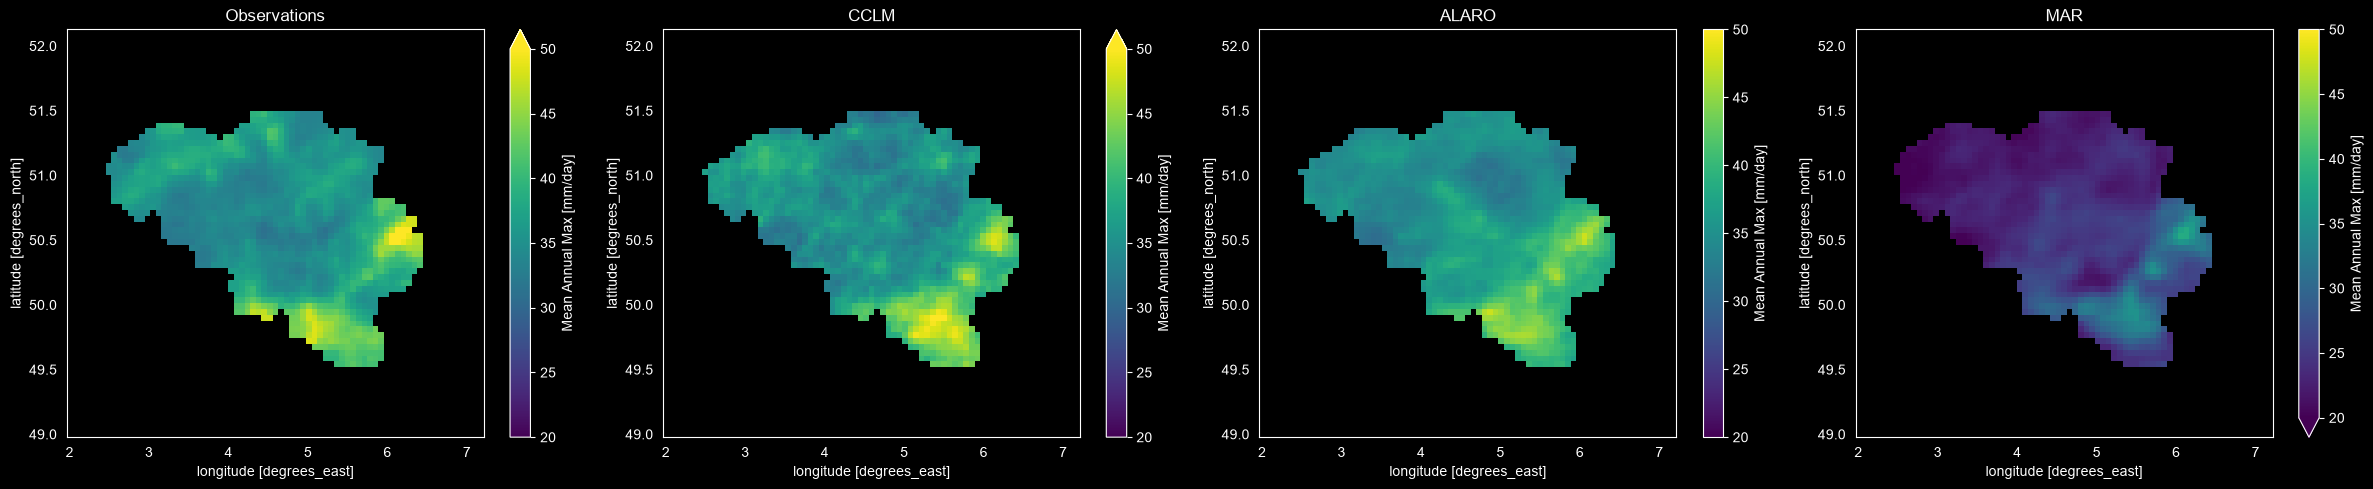

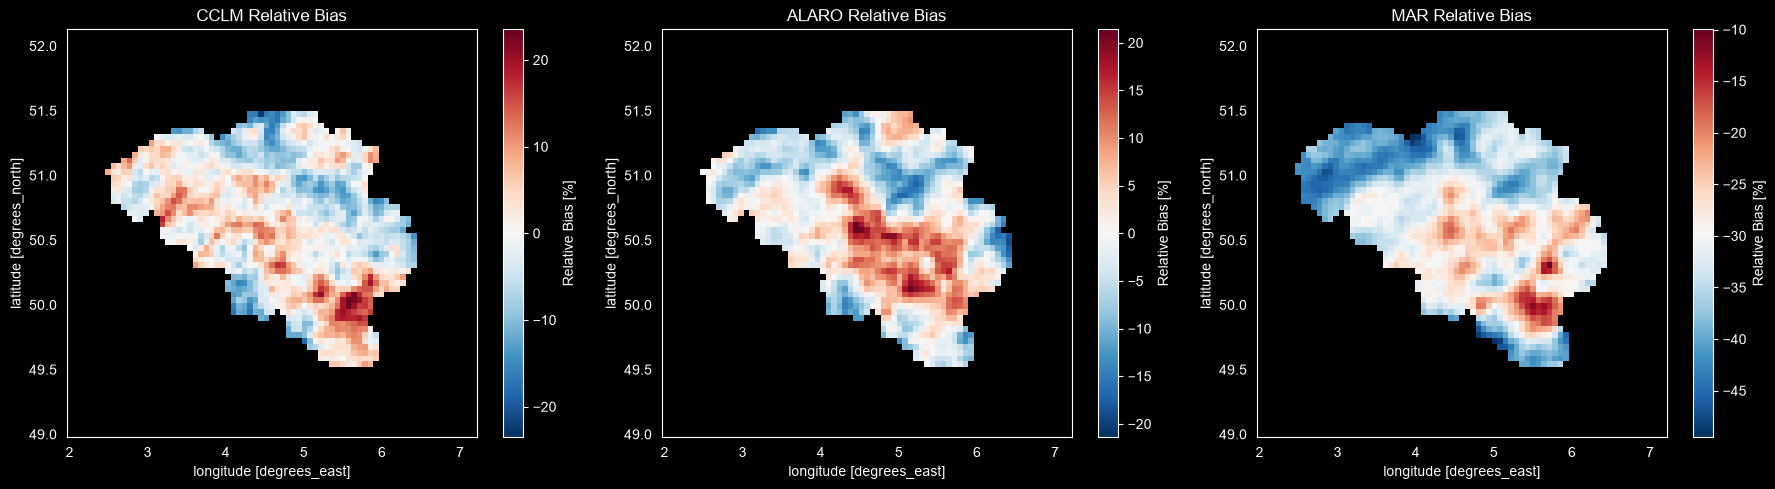

In [19]:
# 1. Use pre-calculated observation annual maxima
mean_max_obs = ann_max_obs.mean(dim='time')
# Dictionary to store the model annual max means for the bias plots
mean_max_models = {}

# 2. Plot 1: Time-mean of the annual maxima (Observations + 3 Models)
# noinspection PyTypeChecker
plt.figure(figsize=(24, 5))

# Plot Observations first
plt.subplot(1, 4, 1)
mean_max_obs.attrs['long_name'] = 'Mean Annual Max'
mean_max_obs.attrs['unit'] = 'mm'
mean_max_obs.plot(vmin = 20, vmax = 50)

plt.title('Observations')

# Loop through models using the pre-calculated dictionary
for i, name in enumerate(models.keys(), start=2):
    plt.subplot(1, 4, i)

    # Use the pre-calculated annual max and store its mean
    ann_max = ann_max_models[name]
    mean_max_models[name] = ann_max.mean(dim='time')

    mean_max_models[name].attrs['long_name'] = 'Mean Annual Max'
    mean_max_models[name].attrs['unit'] = 'mm'
    mean_max_models[name].plot(vmin = 20, vmax = 50)
    plt.title(name)

plt.tight_layout()


# 3. Plot 2: Subplot of the biases (Modelled - Observed)
# noinspection PyTypeChecker
plt.figure(figsize=(18, 5))

for i, (name, mean_max_model) in enumerate(mean_max_models.items(), start=1):
    plt.subplot(1, 3, i)

    # Relative Bias defined as ((Modelled - Observed) / Observed) * 100
    bias = ((mean_max_model - mean_max_obs) / mean_max_obs) * 100
    bias.attrs['long_name'] = 'Relative Bias'
    bias.attrs['units'] = '%'

    bias.plot(cmap='RdBu_r')
    plt.title(f'{name} Relative Bias')

plt.tight_layout()

#### Fig 10 + 11: Time Mean Annual Maxima (values + bias)
 ##### Methodology: Calculated as the average of the maximum daily rainfall recorded each year over the 40-year period (1985–2025) in mm/day. Also extended to relative bias.

 ##### Result + Discussion: MAR really understimates

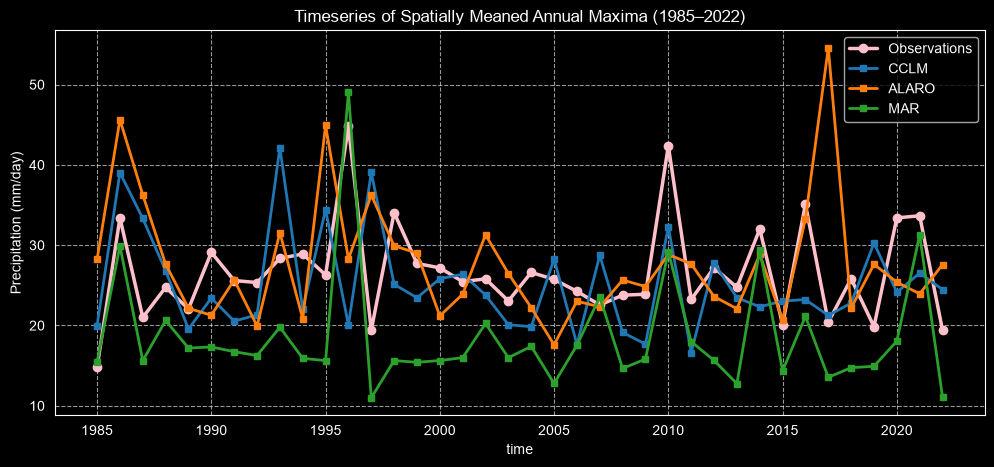

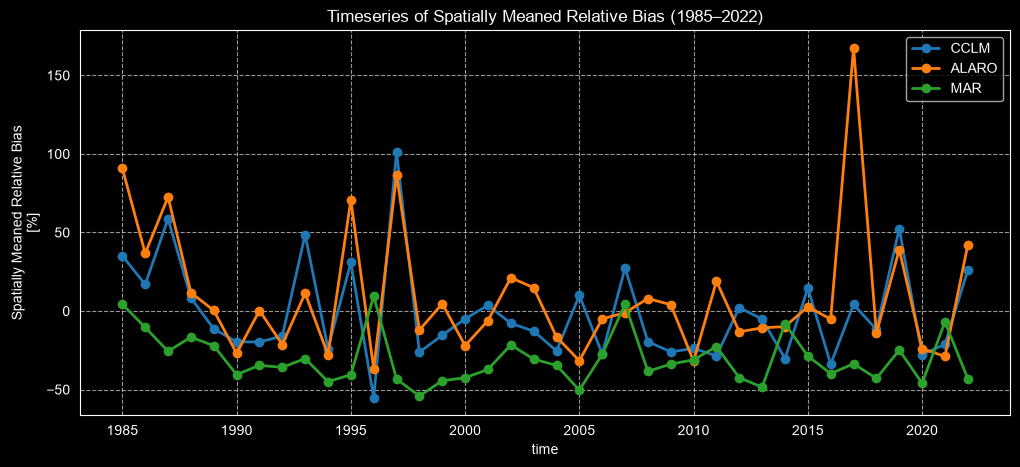

In [20]:
# 1. Pre-calculate annual maxima of the spatial mean (spatial mean first, then annual max)
spatial_mean_max_obs = ds_observations.pr.mean(dim=['lat', 'lon']).resample(time='YE').max()

spatial_mean_max_models_dict = {}
for name, ds in models.items():
    spatial_mean_max_models_dict[name] = ds.pr.mean(dim=['lat', 'lon']).resample(time='YE').max()

# Consistent color palette from the notebook
colors = {'CCLM': '#1f77b4', '#ff7f0e': 'ALARO', 'MAR': '#2ca02c'}
colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}

# ==============================================================================
# --- FIRST PLOT: Raw Values ---
# ==============================================================================
plt.figure(figsize=(12, 5))

# Plot observations raw values
obs_plot = spatial_mean_max_obs.assign_coords(time=spatial_mean_max_obs.time.dt.year)
obs_plot.plot(label='Observations', color='pink', marker='o', linewidth=2.5)

# Plot models raw values
for name, spatial_mean_max_models in spatial_mean_max_models_dict.items():
    model_plot = spatial_mean_max_models.assign_coords(time=spatial_mean_max_models.time.dt.year)
    model_plot.plot(label=name, color=colors[name], marker='s', linewidth=2, markersize=5)

plt.title('Timeseries of Spatially Meaned Annual Maxima (1985–2022)')
plt.ylabel('Precipitation (mm/day)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()


# ==============================================================================
# --- SECOND PLOT: Relative Bias ---
# ==============================================================================
plt.figure(figsize=(12, 5))

for name, spatial_mean_max_models in spatial_mean_max_models_dict.items():
    # Calculate yearly relative bias over space
    yearly_bias = ((spatial_mean_max_models - spatial_mean_max_obs) / spatial_mean_max_obs) * 100

    # Assign attributes to yearly_bias so the plot labels itself correctly
    yearly_bias.attrs['long_name'] = 'Spatially Meaned Relative Bias'
    yearly_bias.attrs['units'] = '%'

    # Clean up the time coordinate to show just the year on the X-axis
    yearly_bias = yearly_bias.assign_coords(time=yearly_bias.time.dt.year)

    # Plot the relative bias using consistent model colors
    yearly_bias.plot(label=name, color=colors[name], marker='o', linewidth=2)

plt.title('Timeseries of Spatially Meaned Relative Bias (1985–2022)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

#### Fig 12 + 13: Space Mean Annual Maxima (values + bias)

##### Methodology: Calculated by first meaning spatially and afterwards selecting the annual maxima, expressed in mm/day as well as in relative bias.

##### Result + Discussion: We see something unusual in 2017. Let's investigate...

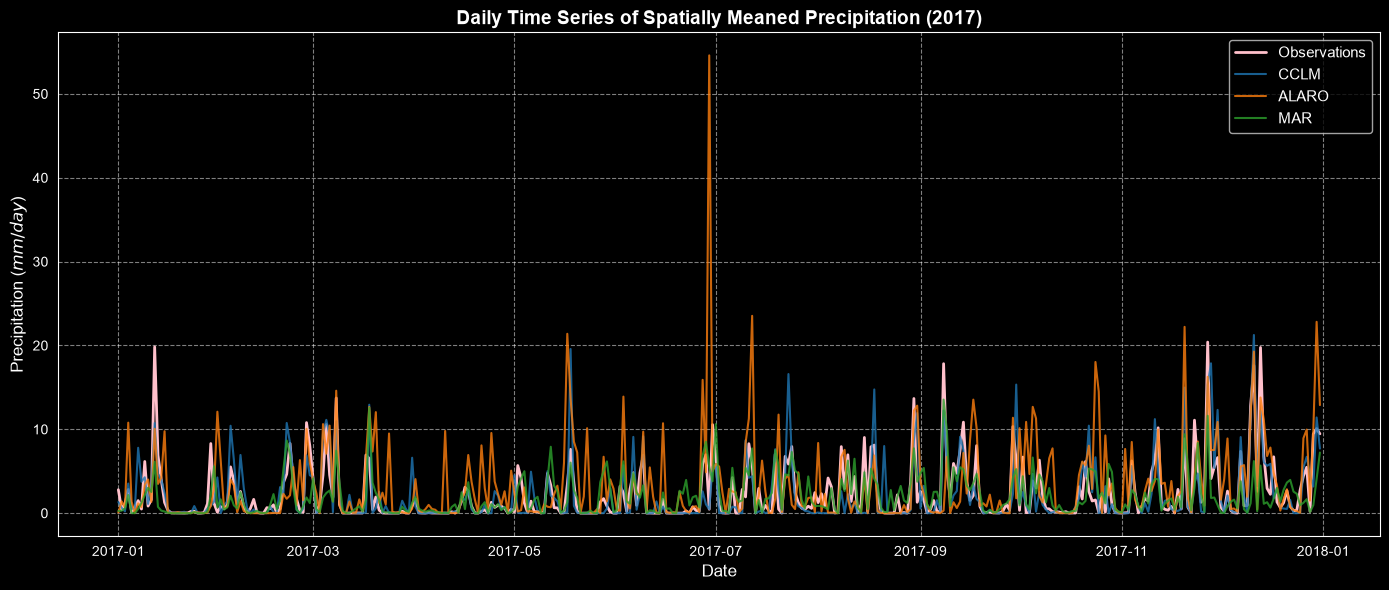

In [21]:
#Investigation of 2017 alaro anomaly
plt.figure(figsize=(14, 6))


# 2. Slice and compute the daily spatial mean for Observations in 2017
obs_2017 = ds_observations['pr'].sel(time='2017').mean(dim=['lat', 'lon'])
plt.plot(obs_2017.time, obs_2017, label='Observations', color='pink', linewidth=2)

# 3. Loop through each model to slice, compute spatial mean, and plot
model_colors = {'CCLM': '#1f77b4', 'ALARO': '#ff7f0e', 'MAR': '#2ca02c'}

for name, ds in models.items():
    model_2017 = ds['pr'].sel(time='2017').mean(dim=['lat', 'lon'])
    plt.plot(
        model_2017.time,
        model_2017,
        label=name,
        color=model_colors.get(name),
        alpha=0.8,
        linewidth=1.5
    )

# 4. Enhance the plot with clear labels, a grid, and a legend
plt.title('Daily Time Series of Spatially Meaned Precipitation (2017)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation ($mm/day$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper right')

# 5. Optimize layout and display
plt.tight_layout()

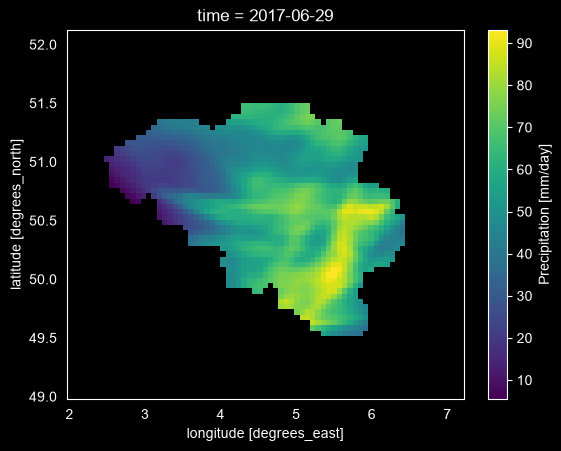

In [22]:
ds_ALARO.pr.sel(time = '2017-06-29').plot()

So a lot of rain this day according to ALARO... But the spatial pattern looks ok.

In [23]:
# Initialize lists to store data for both tables
raw_summary = []
combined_bias_summary = []

# --- 1. Compute Raw Values for Observations (Baseline) ---
# Column 1 Baseline: Spatial Mean first, then Annual Maxima, then Temporal Mean
raw_obs_spatial_first = spatial_mean_max_obs.mean(dim='time').item()

# Column 2 Baseline: Annual Maxima first, then Spatial and Temporal Mean
raw_obs_max_first = ann_max_obs.mean(dim=['time', 'lat', 'lon']).item()

# Append Observation baseline to the raw table summary
raw_summary.append({
    'Model/Dataset': 'Observations',
    'Spatially Averaged Regional Extremes [mm/day]': round(raw_obs_spatial_first, 2),
    'Grid-Point Local Extremes [mm/day]': round(raw_obs_max_first, 2)
})


# --- 2. Compute Raw Values and Biases for All Models ---
for name, ds in models.items():
    # === PATHWAY 1: Spatial Mean first, then Annual Maxima ===
    spatial_mean_max_model = ds.pr.mean(dim=['lat', 'lon']).resample(time='YE').max()

    # Raw value
    raw_model_spatial_first = spatial_mean_max_model.mean(dim='time').item()

    # Relative Bias
    yearly_bias_spatial_first = ((spatial_mean_max_model - spatial_mean_max_obs) / spatial_mean_max_obs) * 100
    overall_mean_bias_spatial_first = yearly_bias_spatial_first.mean(dim='time').item()

    # === PATHWAY 2: Annual Maxima first, then Spatial Mean ===
    ann_max_model = ds.pr.resample(time='YE').max()

    # Raw value
    raw_model_max_first = ann_max_model.mean(dim=['time', 'lat', 'lon']).item()

    # Relative Bias
    yearly_bias_max_first = ((ann_max_model - ann_max_obs) / ann_max_obs) * 100
    overall_mean_bias_max_first = yearly_bias_max_first.mean(dim=['time', 'lat', 'lon']).item()

    # --- Append to respective summary lists ---
    raw_summary.append({
        'Model/Dataset': name,
        'Spatially Averaged Regional Extremes [mm/day]': round(raw_model_spatial_first, 2),
        'Grid-Point Local Extremes [mm/day]': round(raw_model_max_first, 2)
    })

    combined_bias_summary.append({
        'Model': name,
        'Spatially Averaged Regional Extremes Bias [%]': round(overall_mean_bias_spatial_first, 2),
        'Grid-Point Local Extremes Bias [%]': round(overall_mean_bias_max_first, 2)
    })


# --- 3. Display the DataFrames ---
print("--- Table 1: Overall Annual Maxima Raw Intensity Values ---")
df_raw_summary = pd.DataFrame(raw_summary).set_index('Model/Dataset')
display(df_raw_summary)

print("\n--- Table 2: Overall Annual Maxima Relative Bias ---")
df_combined_bias = pd.DataFrame(combined_bias_summary).set_index('Model')
display(df_combined_bias)

--- Table 1: Overall Annual Maxima Raw Intensity Values ---


,Spatially Averaged Regional Extremes [mm/day],Grid-Point Local Extremes [mm/day]
Model/Dataset,,
Observations,26.61,36.89
CCLM,25.15,36.88
ALARO,27.69,36.83
MAR,18.56,24.86



--- Table 2: Overall Annual Maxima Relative Bias ---


,Spatially Averaged Regional Extremes Bias [%],Grid-Point Local Extremes Bias [%]
Model,,
CCLM,-1.40,7.91
ALARO,9.45,8.62
MAR,-30.54,-29.80


#### Table 1 + 2: Overall Annual Maxima (values + bias)

##### Methodology:
Spatially Averaged Regional Extremes Bias: calculated by taking spatial mean first, then taking annual maxima and finally temporal mean, expressed as mm/day and in relative bias.

Grid-Point Local Extremes Bias: calculated by taking Annual maxima first, then taking spatial mean and finally temporal mean,  expressed as mm/day and in relative bias.

##### Result + Discussion:


In [24]:
# Calculate yearly biases (errors) (Modeled - Observed) (bit redundant, but now we properly save it model per model...)
bias_CCLM_yearly = ds_CCLM.pr.resample(time='YE').max() - ann_max_obs
bias_ALARO_yearly = ds_ALARO.pr.resample(time='YE').max() - ann_max_obs
bias_MAR_yearly = ds_MAR.pr.resample(time='YE').max() - ann_max_obs


models_bias = {
    'CCLM': bias_CCLM_yearly,
    'ALARO': bias_ALARO_yearly,
    'MAR': bias_MAR_yearly
}

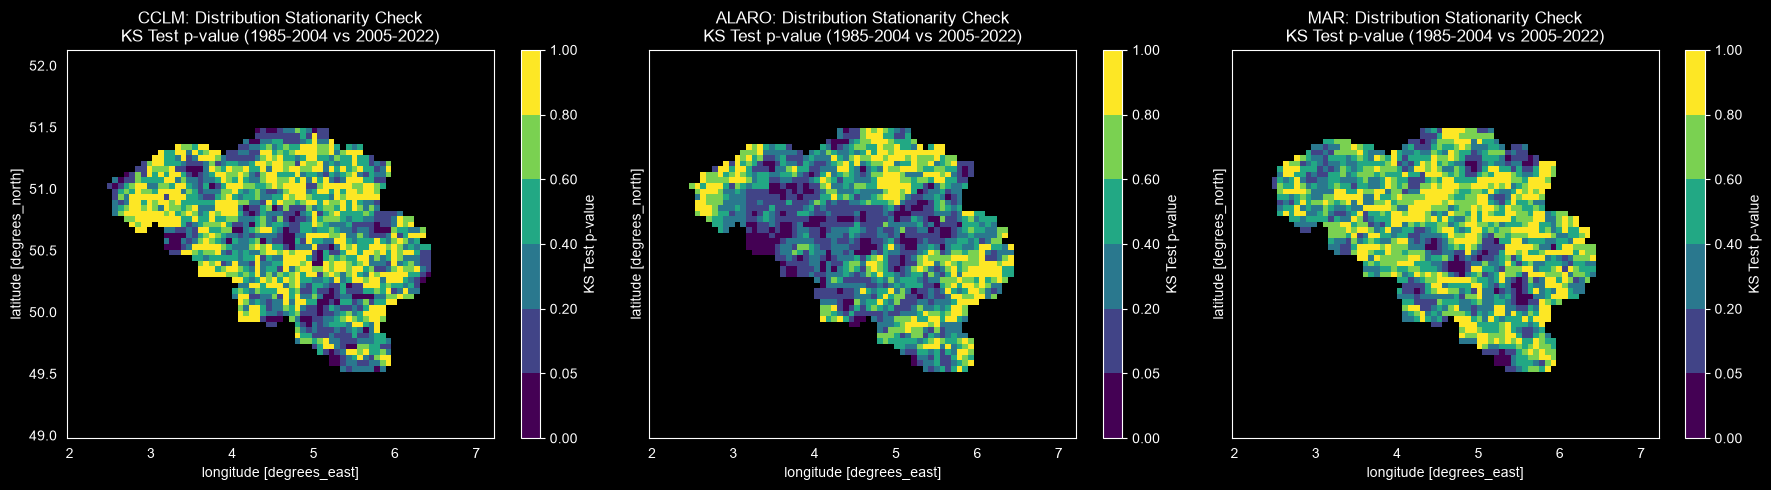

In [25]:
#Performing two sample KS test
from scipy.stats import ks_2samp

# 1. Define a helper function to perform the KS test on a single pixel's time series
def cell_ks_test(x, split_idx):
    era1 = x[:split_idx]
    era2 = x[split_idx:]

    # Drop any potential NaN values safely
    era1 = era1[~np.isnan(era1)]
    era2 = era2[~np.isnan(era2)]

    # Ensure we have enough data points in both eras to perform the test
    if len(era1) == 0 or len(era2) == 0:
        return np.nan, np.nan

    # Two-sample KS test checking if the two distributions differ
    stat, pval = ks_2samp(era1, era2)
    return stat, pval

# 2. Create a 1-row, 3-column subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

for idx, (model_name, bias_da) in enumerate(models_bias.items()):
    ax = axes[idx]

    # Find the boundary index where the year 2005 begins dynamically
    years = bias_da.time.dt.year.values
    split_idx = np.searchsorted(years, 2005)

    # 3. Apply the KS test across the 'time' core dimension for each grid cell
    ks_stat, p_value = xr.apply_ufunc(
        cell_ks_test,
        bias_da,
        input_core_dims=[['time']],
        output_core_dims=[[], []], # Returns two spatial maps: statistic and p-value
        vectorize=True,
        kwargs={'split_idx': split_idx},
        dask='allowed'
    )

    # 4. Plot the map of p-values
    p_value.plot(
        ax=ax,
        cmap='viridis',
        levels=[0, 0.05, 0.2, 0.4, 0.6, 0.8, 1.0], # Force a clean color break exactly at 0.05
        cbar_kwargs={'label': 'KS Test p-value'}
    )

    ax.set_title(f'{model_name}: Distribution Stationarity Check\nKS Test p-value (1985-2004 vs 2005-2022)')

plt.tight_layout()

#### Fig 14: Grid-Cell Distribution Stationarity Check (Two-Sample KS Test)

##### Methodology: Performs a pixel-wise Two-Sample Kolmogorov-Smirnov (KS) Test to evaluate if the model bias distributions are stationary across two distinct climate periods: 1985–2004 vs. 2005–2022. Null Hypothesis ($H_0$): Bias values from both eras are drawn from the same underlying continuous distribution. p < 0.05 indicate a significant change in the bias distribution (non-stationarity) between the two periods.

##### Result + Discussion: Assumption pretty okay (continuous variable, mutually exclusive groups) but assumption of inter and intra independence is a bit shaky... (could be tested...)


In [26]:
#Try linear regression on 1 point. Pr_max = a + b*time

from scipy.stats import linregress
y = bias_CCLM_yearly.isel(lat = 30, lon = 30)
len_y = len(y)
lin_obj = linregress(x= np.arange(len_y) ,y = y) #problem is that linregress doesn't take datetime from xarray so mock variable is introduced
print(f"Slope is: {lin_obj.slope}")
print(f"P-value is: {lin_obj.pvalue}") #H0: slope is zero, HA: slope non-zero
#lin_obj. ...

#help(linregress)

Slope is: -0.013117580784681166
P-value is: 0.9568312594793092


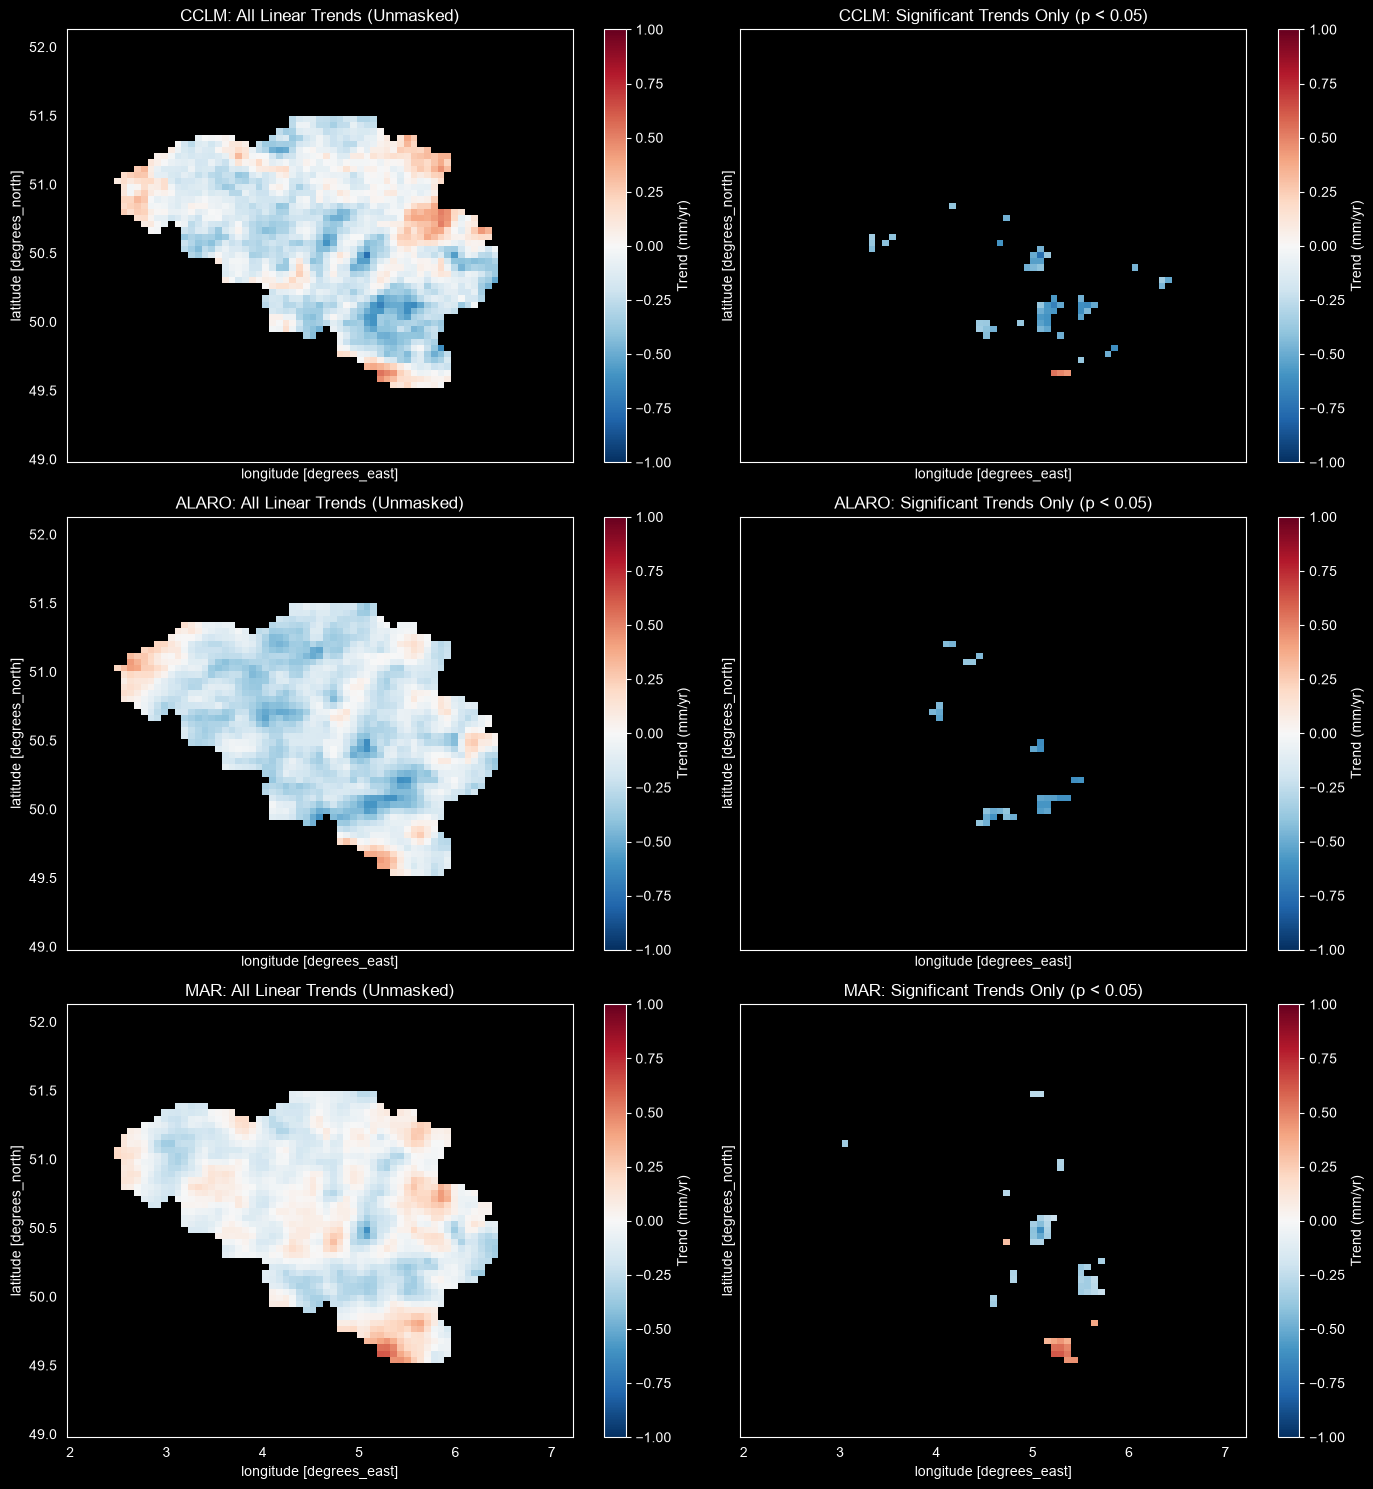

In [27]:
#Extend to map

#from scipy.stats import linregress

# ==========================================
# 1. SETUP WORKFLOW & DATA
# ==========================================
def get_slope_and_pvalue(y):
    """1D function to apply along the time axis."""
    x = np.arange(len(y))
    res = linregress(x, y)
    return res.slope, res.pvalue



alpha = 0.05

# Create a 3-row, 2-column subplot grid
# sharex and sharey ensure x and y axis are exactly the same
fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True, sharey=True)

# ==========================================
# 2. LOOP THROUGH MODELS, COMPUTE & PLOT
# ==========================================
for idx, (model_name, bias_ds) in enumerate(models_bias.items()):

    # Perform linear regression across the yearly bias time series
    slope, p_value = xr.apply_ufunc(
        get_slope_and_pvalue,
        bias_ds,
        input_core_dims=[['time']],
        output_core_dims=[[], []], #slope, p
        vectorize=True,
        dask='allowed' #if it's too much for RAM
    )

    # Mask insignificant values
    significant_slopes = slope.where(p_value < alpha)

    # --- Plot Column 1: Unmasked Trends ---
    ax_unmasked = axes[idx, 0]
    slope.plot(
        ax=ax_unmasked,
        cmap='RdBu_r',
        vmin=-1, vmax=1,
        cbar_kwargs={'label': 'Trend (mm/yr)'}
    )
    ax_unmasked.set_title(f'{model_name}: All Linear Trends (Unmasked)')

    # --- Plot Column 2: Masked Trends ---
    ax_masked = axes[idx, 1]
    significant_slopes.plot(
        ax=ax_masked,
        cmap='RdBu_r',
        vmin=-1, vmax=1,
        cbar_kwargs={'label': 'Trend (mm/yr)'}
    )
    ax_masked.set_title(f'{model_name}: Significant Trends Only (p < {alpha})')

plt.tight_layout()

#### Fig 15: Linear trends in bias of annual maxima

##### Methodology: Calculated by performing a pixel-wise linear regression over the yearly bias time series for each model (CCLM, ALARO, and MAR). The left column displays all calculated linear slopes (unmasked), while the right column filters the domain to display only the grid cells where the trend is statistically significant (p < 0.05).

##### Result + Discussion: Looks like it is stationary but naive idea; noise is too great to detect any signal if it even exists. Additionally, type I error problems. Also problems conditions linear regression...

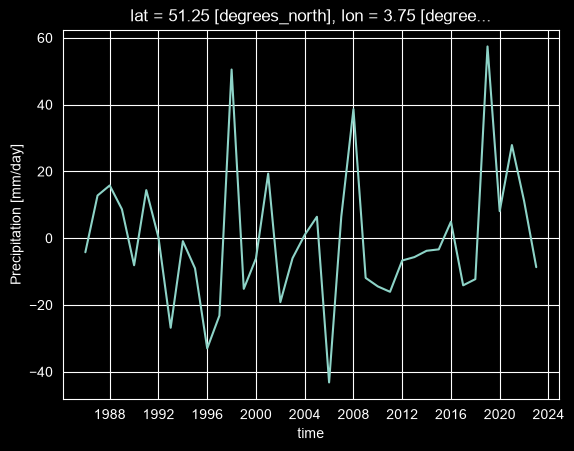

In [28]:
#Random test example of noise
bias_CCLM_yearly.isel(lat = 50, lon = 25).plot()

#noisy!

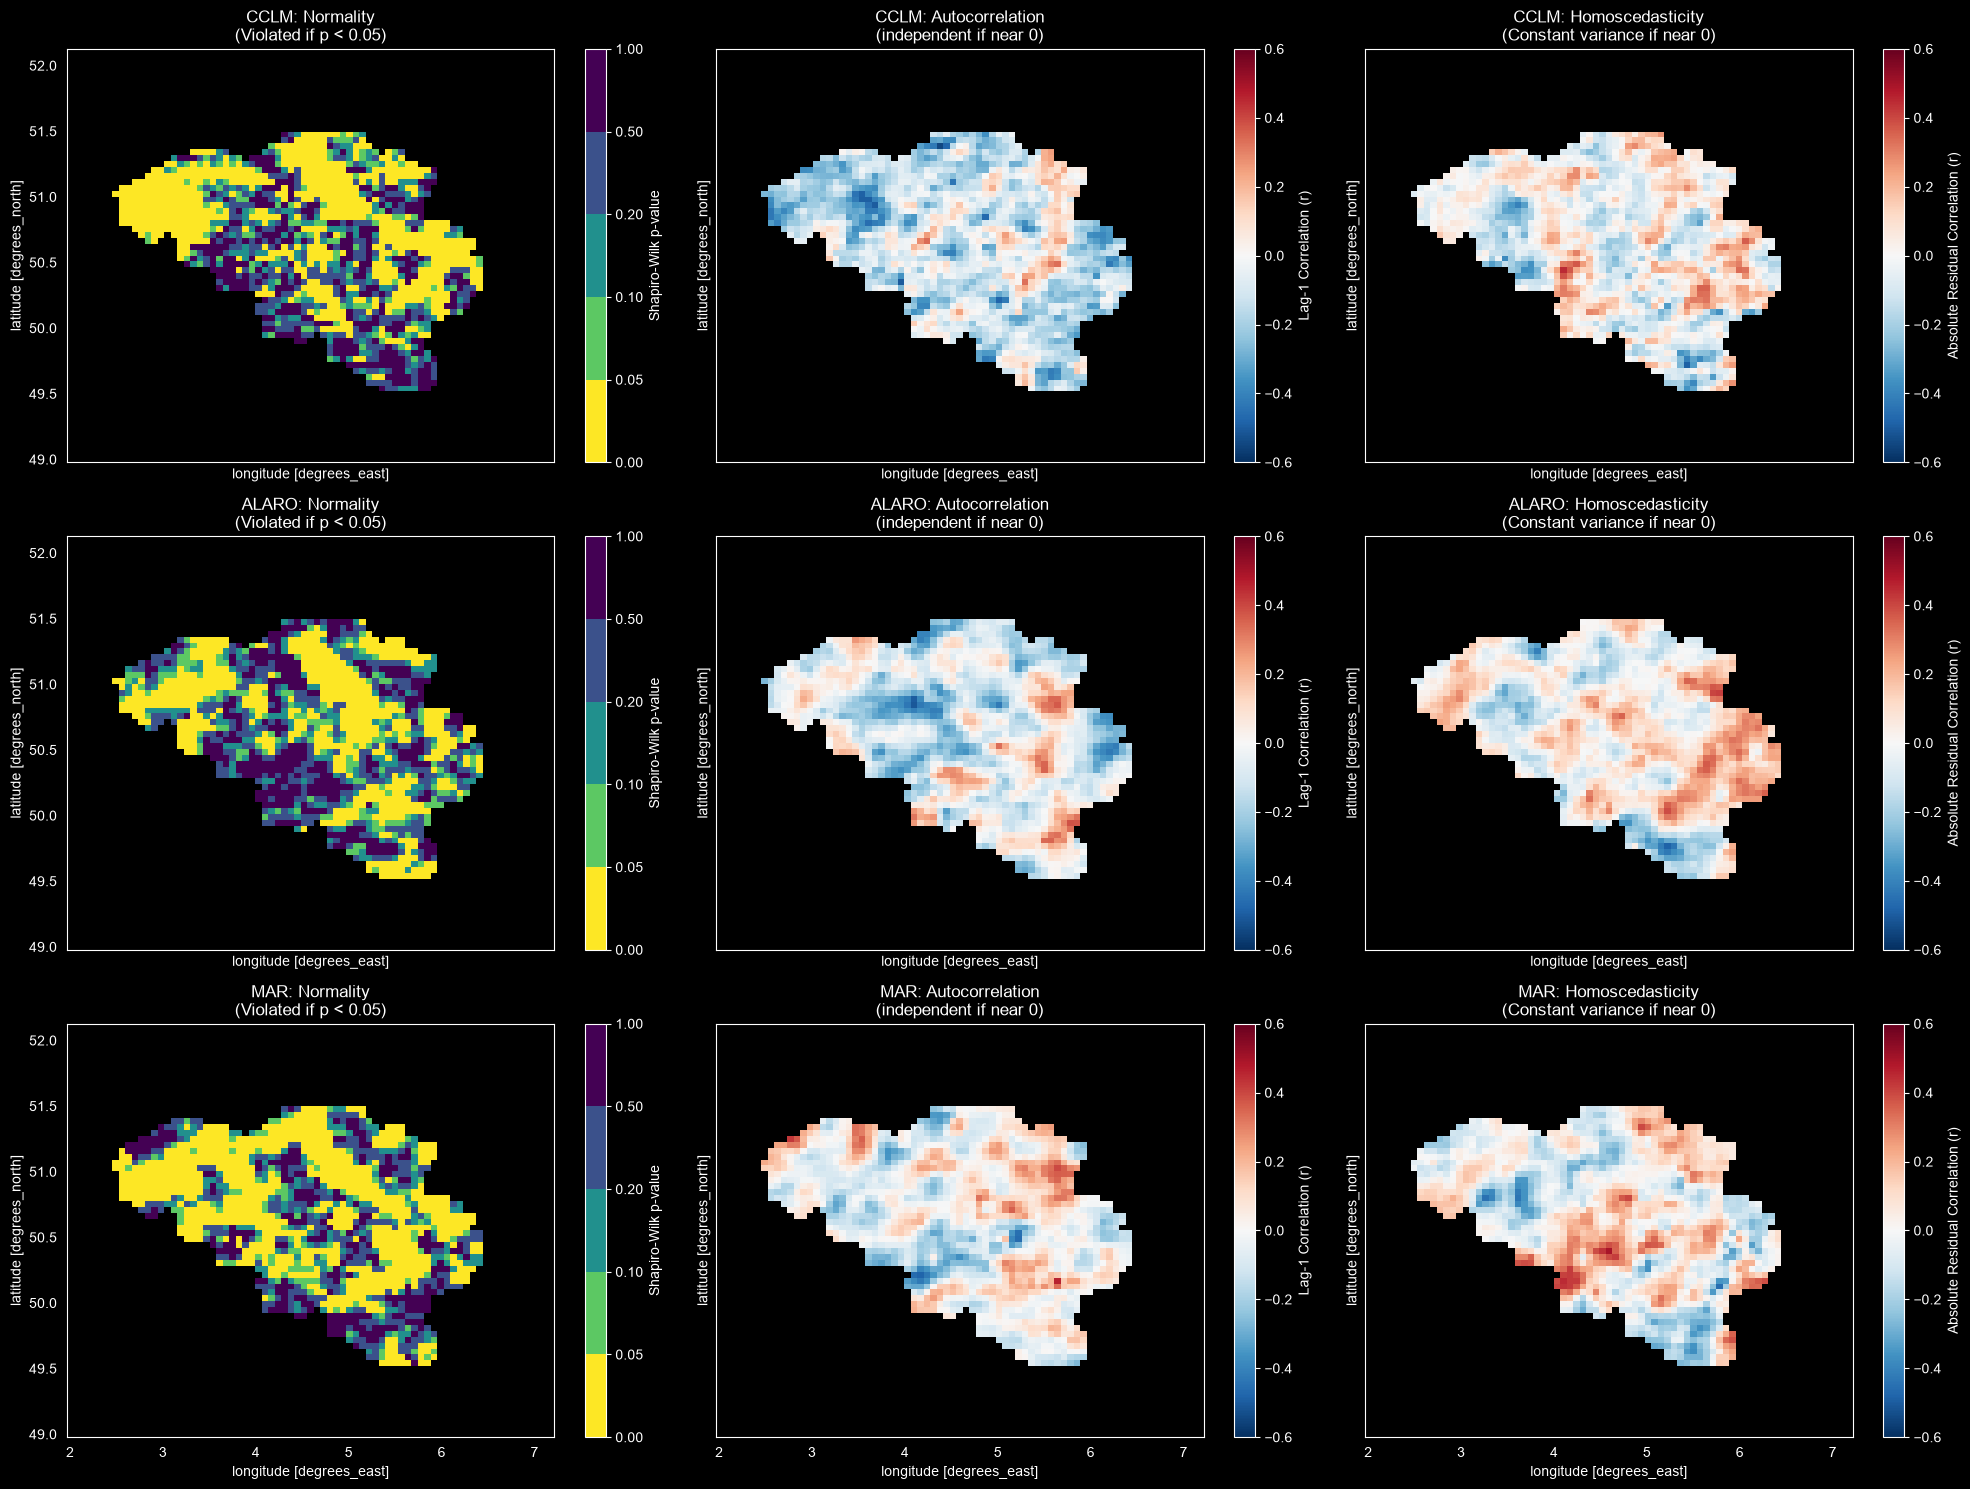

In [29]:
from scipy.stats import shapiro, linregress
# ==============================================================================
# 1. SETUP ASSUMPTION CHECKING WORKFLOW
# ==============================================================================
def verify_assumptions(y):
    """
    Calculates regression residuals and tests three core OLS assumptions:
    1. Normality (Shapiro-Wilk p-value)
    2. Independence (Lag-1 Autocorrelation)
    3. Homoscedasticity (Correlation of absolute residuals over time)
    """
    x = np.arange(len(y))

    # Handle any potential grid-edge NaNs safely
    mask = ~np.isnan(y)
    if np.sum(mask) < 5:  # Require a minimum sample size to perform tests
        return np.nan, np.nan, np.nan

    # Fit the linear model to extract residuals
    res = linregress(x[mask], y[mask])
    fitted_values = res.intercept + res.slope * x[mask]
    residuals = y[mask] - fitted_values

    # Assumption 1: Normality Test (Shapiro-Wilk)
    # H0: Residuals are normally distributed (We want p > 0.05)
    _, p_normality = shapiro(residuals)

    # Assumption 2: Independence (Lag-1 Autocorrelation)
    # r near 0 = Independent errors; r far from 0 = Violated i.i.d.
    if len(residuals) > 2:
        r_lag1 = np.corrcoef(residuals[:-1], residuals[1:])[0, 1]
    else:
        r_lag1 = np.nan

    # Assumption 3: Homoscedasticity (Constant Variance over Time)
    # Proxy: Check if the magnitude (absolute value) of residuals changes with time.
    # r near 0 = Homoscedastic (good); r far from 0 = Heteroscedastic (bad)
    if len(residuals) > 2:
        r_homo = np.corrcoef(np.abs(residuals), x[mask])[0, 1]
    else:
        r_homo = np.nan

    return p_normality, r_lag1, r_homo


# ==============================================================================
# 2. GRID PLOTTING SETUP (3 Rows for Models x 3 Columns for Assumptions)
# ==============================================================================
# We expand the grid to 3 columns to visually inspect all three assumptions.
fig, axes = plt.subplots(3, 3, figsize=(20, 15), sharex=True, sharey=True)

# ==============================================================================
# 3. LOOP THROUGH MODELS, EVALUATE & PLOT
# ==============================================================================
for idx, (model_name, bias_ds) in enumerate(models_bias.items()):

    # Apply the verification function across the 'time' dimension
    # It now safely expects and unpacks 3 distinct output DataArrays
    p_norm, r_autocorr, r_homo = xr.apply_ufunc(
        verify_assumptions,
        bias_ds,
        input_core_dims=[['time']],
        output_core_dims=[[], [], []],  # Handles 3 outputs
        vectorize=True,
        dask='allowed'
    )

    # --- Plot Column 1: Normality Check (Shapiro-Wilk p-value) ---
    ax_norm = axes[idx, 0]
    p_norm.plot(
        ax=ax_norm,
        cmap='viridis_r',  # Yellow/Green = Passed; Dark Purple = Violated (p < 0.05)
        levels=[0, 0.05, 0.1, 0.2, 0.5, 1.0],
        cbar_kwargs={'label': 'Shapiro-Wilk p-value'}
    )
    ax_norm.set_title(f'{model_name}: Normality\n(Violated if p < 0.05)')

    # --- Plot Column 2: Independence Check (Lag-1 Autocorrelation) ---
    ax_ind = axes[idx, 1]
    r_autocorr.plot(
        ax=ax_ind,
        cmap='RdBu_r',  # White/Light = Independent (r ~ 0); Dark Red/Blue = Autocorrelated
        vmin=-0.6, vmax=0.6,
        cbar_kwargs={'label': 'Lag-1 Correlation (r)'}
    )
    ax_ind.set_title(f'{model_name}: Autocorrelation\n(independent if near 0)')

    # --- Plot Column 3: Homoscedasticity Check (Magnitude Trend over Time) ---
    ax_homo = axes[idx, 2]
    r_homo.plot(
        ax=ax_homo,
        cmap='RdBu_r',  # White/Light = Homoscedastic (r ~ 0); Dark Red/Blue = Heteroscedastic
        vmin=-0.6, vmax=0.6,
        cbar_kwargs={'label': 'Absolute Residual Correlation (r)'}
    )
    ax_homo.set_title(f'{model_name}: Homoscedasticity\n(Constant variance if near 0)')

# Clean up axes labels and optimize presentation
plt.tight_layout()

Conditions don't look great... => GEV!

In [30]:
#from pyextremes import EVA
#help(EVA)

C:\Users\Maxim\anaconda3\envs\heatwaves_rmi\Lib\site-packages\pyextremes\eva.py:131: RuntimeWarning: 105 Null values found in `data` - removing invalid entries
  warnings.warn(message=message, category=RuntimeWarning)


                     Kolmogorov-Smirnov Test                      
------------------------------------------------------------------
Null hypothesis: data follows gumbel_r distribution               
Alternative hypothesis: data doesn't follow gumbel_r distribution 
                                                                  
Test statistic: D = 0.08615069130682118                           
p-value: 0.9175708079440348                                       
                                                                  
Significance level: 0.05                                          
Critical value: 0.21543864215654732                               
Critical region: reject null-hypothesis if D > 0.21543864215654732
                                                                  
Test result: data follows gumbel_r distribution                   
------------------------------------------------------------------
AIC: 276.4570690003038
loglikelihood: -136.05710592872333


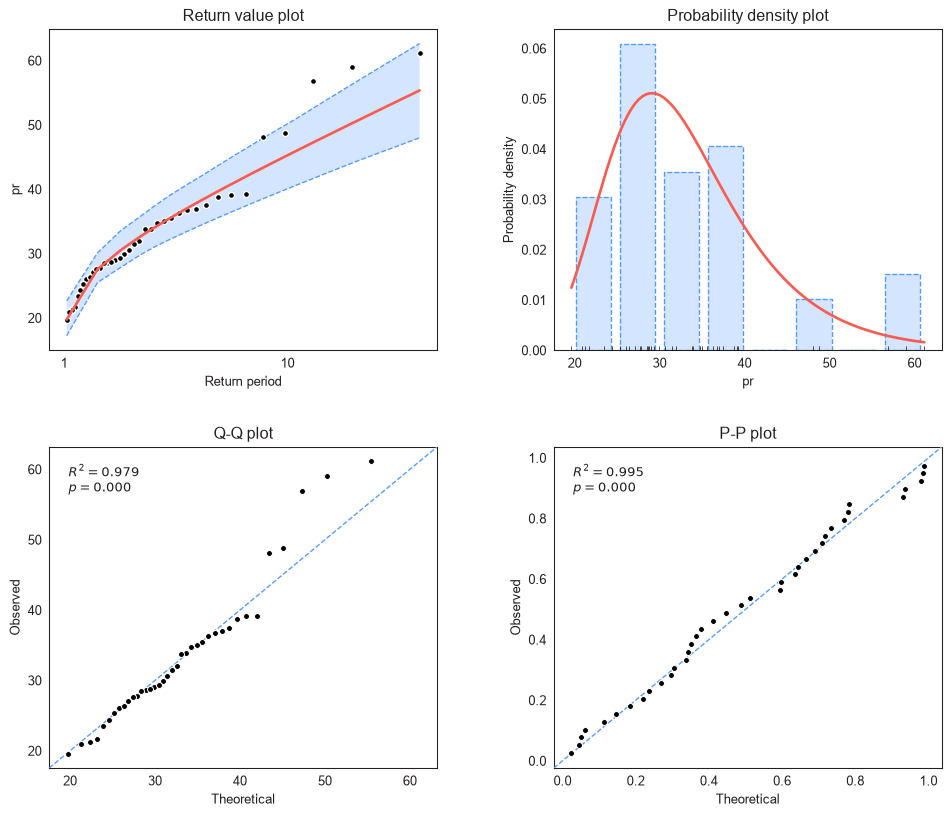

In [31]:
#Fit GEV to one pixel
from pyextremes import EVA

pd_series_rp = ds_CCLM.pr.isel(lat=51, lon=40).to_series() #convert to panda

# 2. Initialize the Extreme Value Analysis object
model = EVA(data=pd_series_rp)
model.get_extremes(method="BM", block_size="365.2425D") #Annual maxima
model.fit_model(model="MLE")
#model.get_summary(return_period = [20], return_period_size = '365.2425D', alpha = 0.95)
print(model.test_ks()) #Kolmogorov-Smirnov test with H0 that data belongs to fitted GEV, HA data does not.
print(f"AIC: {model.AIC}")
print(f"loglikelihood: {model.loglikelihood}")

# Plot the full 4-panel
fig, ax = model.plot_diagnostic(alpha=0.95, figsize=(12, 10))

# Plot only return value plot
#fig, ax = model.plot_return_values(alpha=0.95, figsize=(9, 5))